# Exercise for k means tutorial

Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features. Drop other two features for simplicity.

Figure out if any preprocessing such as scaling would help here

Draw elbow plot and from that figure out optimal value of k

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris

In [3]:
iris=load_iris()

In [4]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [29]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [30]:
df.drop(['sepal length (cm)', 'sepal width (cm)'], axis=1, inplace=True)

In [31]:
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


# Scale the Data

In [39]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [41]:
df_scaled

array([[0.06779661, 0.04166667],
       [0.06779661, 0.04166667],
       [0.05084746, 0.04166667],
       [0.08474576, 0.04166667],
       [0.06779661, 0.04166667],
       [0.11864407, 0.125     ],
       [0.06779661, 0.08333333],
       [0.08474576, 0.04166667],
       [0.06779661, 0.04166667],
       [0.08474576, 0.        ],
       [0.08474576, 0.04166667],
       [0.10169492, 0.04166667],
       [0.06779661, 0.        ],
       [0.01694915, 0.        ],
       [0.03389831, 0.04166667],
       [0.08474576, 0.125     ],
       [0.05084746, 0.125     ],
       [0.06779661, 0.08333333],
       [0.11864407, 0.08333333],
       [0.08474576, 0.08333333],
       [0.11864407, 0.04166667],
       [0.08474576, 0.125     ],
       [0.        , 0.04166667],
       [0.11864407, 0.16666667],
       [0.15254237, 0.04166667],
       [0.10169492, 0.04166667],
       [0.10169492, 0.125     ],
       [0.08474576, 0.04166667],
       [0.06779661, 0.04166667],
       [0.10169492, 0.04166667],
       [0.

# Elbow Method

In [46]:
sse=[]
for k in range(1,11):
    km=KMeans(n_clusters=k)
    km.fit(df_scaled)
    sse.append(km.inertia_)

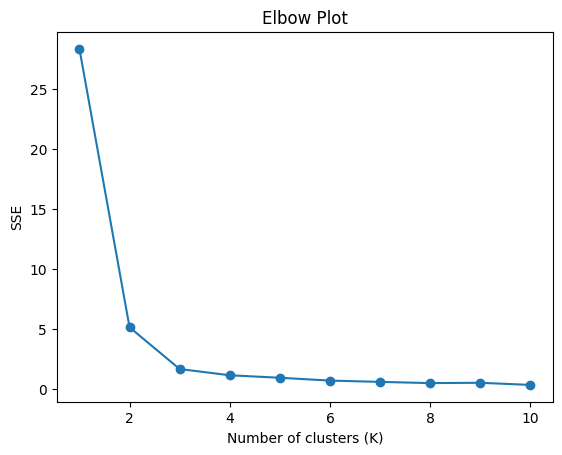

In [47]:
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE')
plt.title('Elbow Plot')
plt.show()

# Choose Optimal K

In [51]:
km = KMeans(n_clusters=3)
km.fit(df_scaled)
y_pred = km.predict(df_scaled)
df['cluster'] = y_pred
df.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


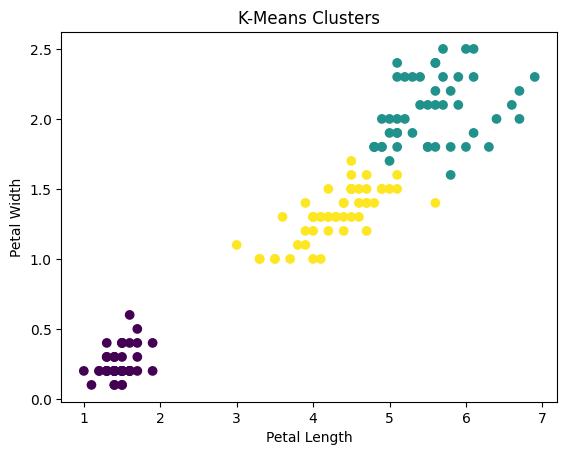

In [52]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['cluster'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clusters')
plt.show()